In [304]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.feature_selection import VarianceThreshold
from sklearn.feature_selection import SelectKBest, f_regression
from sklearn.linear_model import Lasso, LinearRegression
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.inspection import permutation_importance
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.model_selection import RandomizedSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.metrics import accuracy_score, precision_score, recall_score

df = pd.read_csv('customer_churn.csv', index_col=0)

# 1. Project Objective

Clearly state the purpose:

- Find what makes a customer leave?

What questions are we trying to answer?

- What makes a customer stay?

Why does this question matter to stakeholders?

- To keep the $ coming in.

# 2. Data Overview

In [305]:
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [306]:
df.columns

Index(['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
       'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
       'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod',
       'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [307]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   object 
 1   SeniorCitizen     7043 non-null   int64  
 2   Partner           7043 non-null   object 
 3   Dependents        7043 non-null   object 
 4   tenure            7043 non-null   int64  
 5   PhoneService      7043 non-null   object 
 6   MultipleLines     7043 non-null   object 
 7   InternetService   7043 non-null   object 
 8   OnlineSecurity    7043 non-null   object 
 9   OnlineBackup      7043 non-null   object 
 10  DeviceProtection  7043 non-null   object 
 11  TechSupport       7043 non-null   object 
 12  StreamingTV       7043 non-null   object 
 13  StreamingMovies   7043 non-null   object 
 14  Contract          7043 non-null   object 
 15  PaperlessBilling  7043 non-null   object 
 16  PaymentMethod     7043 non-null   object 
 17  

In [308]:
X = df.drop(columns=['Churn', 'PhoneService', 'TotalCharges'])

df['Churn'] = df['Churn'].map({
    'Yes': 1,
    'No': 0
})

y = df['Churn']

X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=.2, random_state=42)

X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=.25, random_state=42)

In [309]:
numerical_cols = ['tenure', 'MonthlyCharges']
categorical_cols = df.drop(columns=['tenure', 'MonthlyCharges', 'PhoneService', 'TotalCharges', 'Churn']).columns.tolist()
#ordinal_cols = ["Contract"]

In [310]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges,Churn
count,7043.000000,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692,0.265370
std,0.368612,24.559481,30.090047,0.441561
min,0.000000,0.000000,18.250000,0.000000
25%,0.000000,9.000000,35.500000,0.000000
50%,0.000000,29.000000,70.350000,0.000000
75%,0.000000,55.000000,89.850000,1.000000
max,1.000000,72.000000,118.750000,1.000000


In [311]:
#This is where we left off.

In [312]:
# Creating pipeline



    
# }

preprocessor = ColumnTransformer(transformers=[
    ('ohe', OneHotEncoder(sparse_output=False), categorical_cols),
    ('scaler', StandardScaler(), numerical_cols),
    #('Ordinal', OrdinalEncoder(), ordinal_cols)
], verbose_feature_names_out=False)


pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('model', XGBClassifier(
        n_estimators=100, 
        learning_rate=0.01, 
        random_state=42, 
        eval_metric="logloss", 
        verbosity=0))
])


pipe.fit(X_train, y_train)

#y_pred = pipe.predict(X_test)
#acc_score = accuracy_score(y_test, y_pred)

y_train_pred = pipe.predict(X_train)
acc_score_train = accuracy_score(y_train, y_train_pred)

print(acc_score_train)
# rs = RandomizedSearchCV(pipe, param_grid, n_iter=20, random_state=42)
# rs.fit(X_train, y_train)

feature_names = preprocessor.get_feature_names_out().tolist()

0.8085207100591716


In [313]:
param_grid = {
    "model__n_estimators": [100, 200, 300, 400, 500, 1000],
    "model__learning_rate": [.1, .08, .06, .04, .02, .01]
}

gs = GridSearchCV(pipe, param_grid, cv=5, scoring="precision", n_jobs=-1)

gs.fit(X_temp, y_temp)

,estimator,"Pipeline(step...=None, ...))])"
,param_grid,"{'model__learning_rate': [0.1, 0.08, ...], 'model__n_estimators': [100, 200, ...]}"
,scoring,'precision'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,transformers,"[('ohe', ...), ('scaler', ...)]"


In [314]:
for k, v in gs.best_params_.items():
    print(f"  {k}: {v}")
print("Best CV R2 :", round(gs.best_score_, 3))   # avg across 5 folds
print("Test f1    :", round(gs.score(X_test, y_test), 3))  # final hold-out

  model__learning_rate: 0.01
  model__n_estimators: 100
Best CV R2 : 0.766
Test f1    : 0.804


In [315]:
# Validation dataset

y_pred_val = pipe.predict(X_val)
acc_score_val = accuracy_score(y_val, y_pred_val)
precision = precision_score(y_val, y_pred_val)
recall = recall_score(y_val, y_pred_val)

print("accuracy: ", acc_score_val)
print("precision: ", precision)
print("recall: ", recall)


accuracy:  0.7814052519517388
precision:  0.7028571428571428
recall:  0.3245382585751979


In [316]:
# Test dataset

y_pred_test = pipe.predict(X_test)
acc_score_test = accuracy_score(y_test, y_pred_test)
precision_test = precision_score(y_test, y_pred_test)
recall_test = recall_score(y_test, y_pred_test)

print("accuracy: ", acc_score_test)
print("precision: ", precision_test)
print("recall: ", recall_test)

accuracy:  0.7970191625266146
precision:  0.7668711656441718
recall:  0.3351206434316354


# 3. Data Overview

1. Which features showed the strongest relationship/predictive potential?
-  Fiber optics/internet service is #1, and locking your customers into a contract prevents them from leaving.

In [317]:
importances = pd.Series(pipe.named_steps['model'].feature_importances_, index=pipe.named_steps['preprocessor'].get_feature_names_out()).sort_values(ascending=False)

print(importances)

Contract_Month-to-month                    0.676551
OnlineSecurity_No                          0.048616
InternetService_DSL                        0.041393
InternetService_Fiber optic                0.040837
TechSupport_No                             0.031554
tenure                                     0.016103
Contract_One year                          0.011990
PaymentMethod_Electronic check             0.011357
MonthlyCharges                             0.009944
StreamingMovies_Yes                        0.009649
MultipleLines_No phone service             0.009344
OnlineBackup_No                            0.008605
OnlineBackup_Yes                           0.008416
MultipleLines_No                           0.008221
PaymentMethod_Bank transfer (automatic)    0.006880
PaperlessBilling_No                        0.006625
Dependents_No                              0.006548
StreamingMovies_No                         0.006483
SeniorCitizen_0                            0.006135
PaymentMetho

In [318]:

lin_pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('model', LinearRegression())
])

lin_pipe.fit(X_temp, y_temp)

#print(lin_pipe.named_steps["model"].coef_)


lin_score= {}

for name, coef in zip(lin_pipe.named_steps['preprocessor'].get_feature_names_out(), lin_pipe.named_steps["model"].coef_):
    lin_score[name] = coef
    #print(f"  {name}: {coef:.2f}")

lin_score_sorted = pd.Series(lin_score).sort_values(ascending=False)
lin_score_sorted

InternetService_Fiber optic                0.158423
StreamingMovies_Yes                        0.071493
StreamingTV_Yes                            0.062328
MultipleLines_Yes                          0.061079
Contract_Month-to-month                    0.060064
PaymentMethod_Electronic check             0.059864
OnlineSecurity_No                          0.044255
TechSupport_No                             0.039959
OnlineBackup_No                            0.028289
DeviceProtection_Yes                       0.027589
PaperlessBilling_Yes                       0.022584
SeniorCitizen_1                            0.019240
DeviceProtection_No                        0.015511
OnlineBackup_Yes                           0.014812
Dependents_No                              0.010685
gender_Female                              0.004692
TechSupport_Yes                            0.003142
Partner_Yes                                0.003114
OnlineSecurity_Yes                        -0.001155
Partner_No  

# Group and Plot

### Monthly Charges

grouped_monthly_charges
Less than 30    10
30-50           31
50-70           21
70-90           38
90-110          36
110+            13
Name: Churn, dtype: int64


C:\Users\jesse\AppData\Local\Temp\ipykernel_18700\2110619576.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  perc = (round(df.groupby("grouped_monthly_charges")["Churn"].mean() * 100, 0)).astype(int)


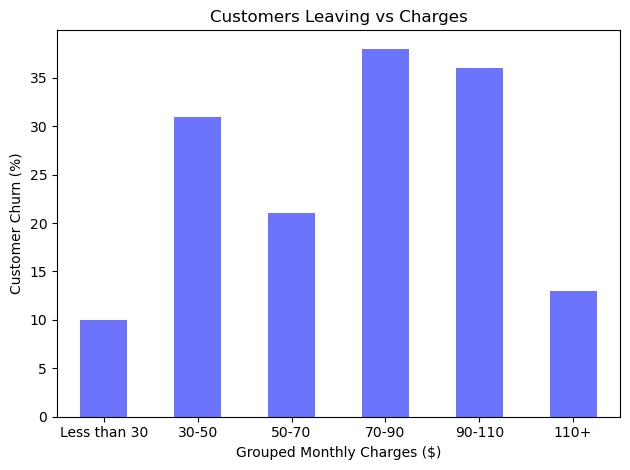

In [319]:
df['grouped_monthly_charges'] = pd.cut(df['MonthlyCharges'], bins=[0, 30, 50, 70, 90, 110, 130], labels=['Less than 30', '30-50','50-70','70-90','90-110','110+'])
perc = (round(df.groupby("grouped_monthly_charges")["Churn"].mean() * 100, 0)).astype(int)
print(perc)
# plt.figure(facecolor='#292d3e')
# plt.gca().set_facecolor('#292d3e')
perc.plot(kind='bar', rot=0, color="#6c73fd")
plt.ylabel('Customer Churn (%)')
plt.xlabel(f'Grouped Monthly Charges ($)')
plt.title(f'Customers Leaving vs Charges')
plt.tight_layout()
plt.show()

In [320]:
df['MonthlyCharges'].describe()

count    7043.000000
mean       64.761692
std        30.090047
min        18.250000
25%        35.500000
50%        70.350000
75%        89.850000
max       118.750000
Name: MonthlyCharges, dtype: float64

In [321]:
def group_and_plot(feature_lst):
    for feat in feature_lst:
        perc = (round(df.groupby(feat)["Churn"].mean().sort_values(ascending=False) * 100, 0)).astype(int)
        print(perc)
        # plt.figure(facecolor='#292d3e')
        # plt.gca().set_facecolor('#292d3e')
        perc.plot(kind='bar', rot=0, color="#6c73fd")
        plt.ylabel('Customer Churn (%)')
        plt.xlabel(f'{feat}')
        plt.title(f'Customers Leaving vs {feat}')
        plt.show()
        # print(feat)

Contract
Month-to-month    43
One year          11
Two year           3
Name: Churn, dtype: int64


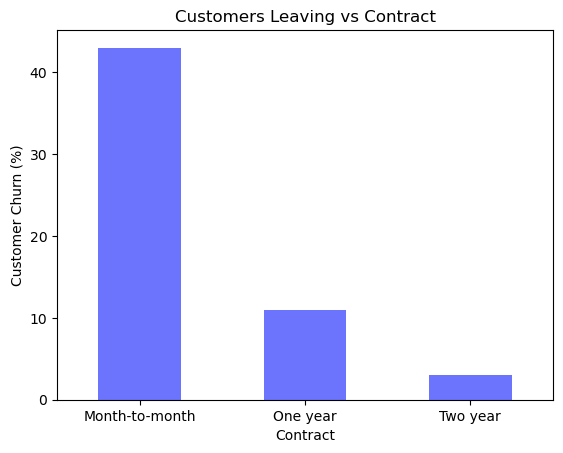

InternetService
Fiber optic    42
DSL            19
No              7
Name: Churn, dtype: int64


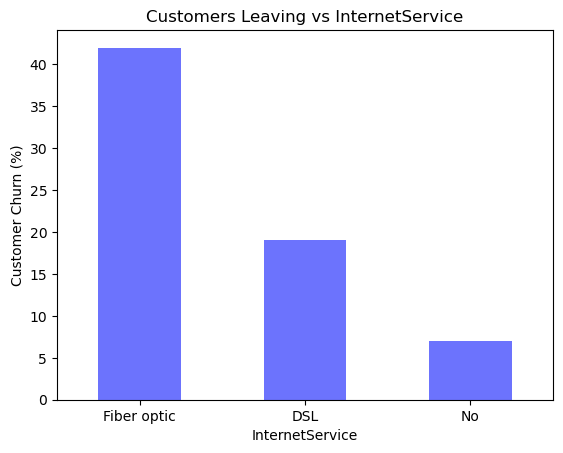

TechSupport
No                     42
Yes                    15
No internet service     7
Name: Churn, dtype: int64


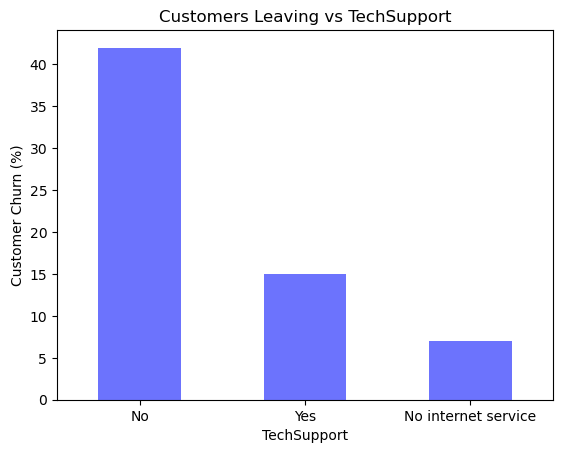

OnlineSecurity
No                     42
Yes                    15
No internet service     7
Name: Churn, dtype: int64


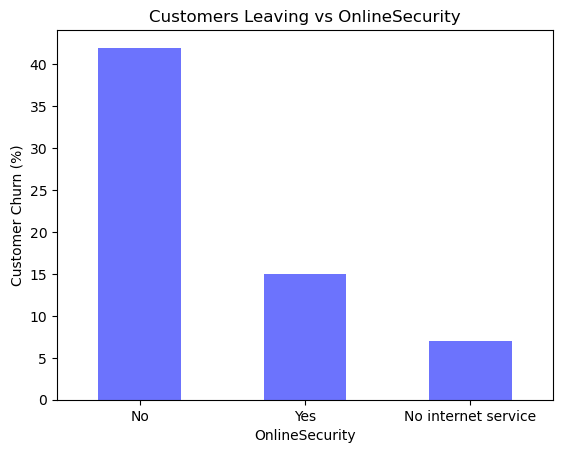

grouped_monthly_charges
70-90           38
90-110          36
30-50           31
50-70           21
110+            13
Less than 30    10
Name: Churn, dtype: int64


C:\Users\jesse\AppData\Local\Temp\ipykernel_18700\592495471.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  perc = (round(df.groupby(feat)["Churn"].mean().sort_values(ascending=False) * 100, 0)).astype(int)


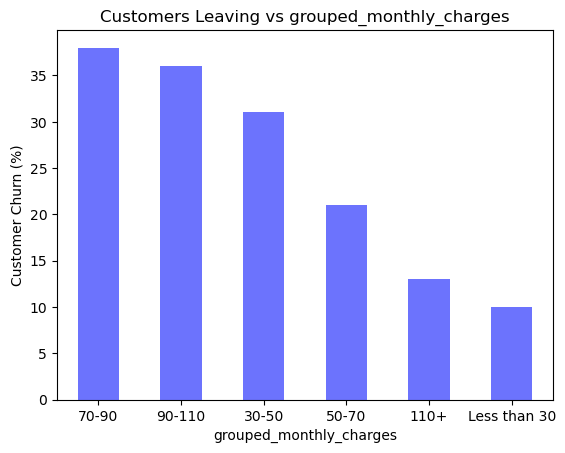

In [322]:
feat_lst = ['Contract', 'InternetService', 'TechSupport', 'OnlineSecurity', 'grouped_monthly_charges']

group_and_plot(feat_lst)

### Monthly Charges v2

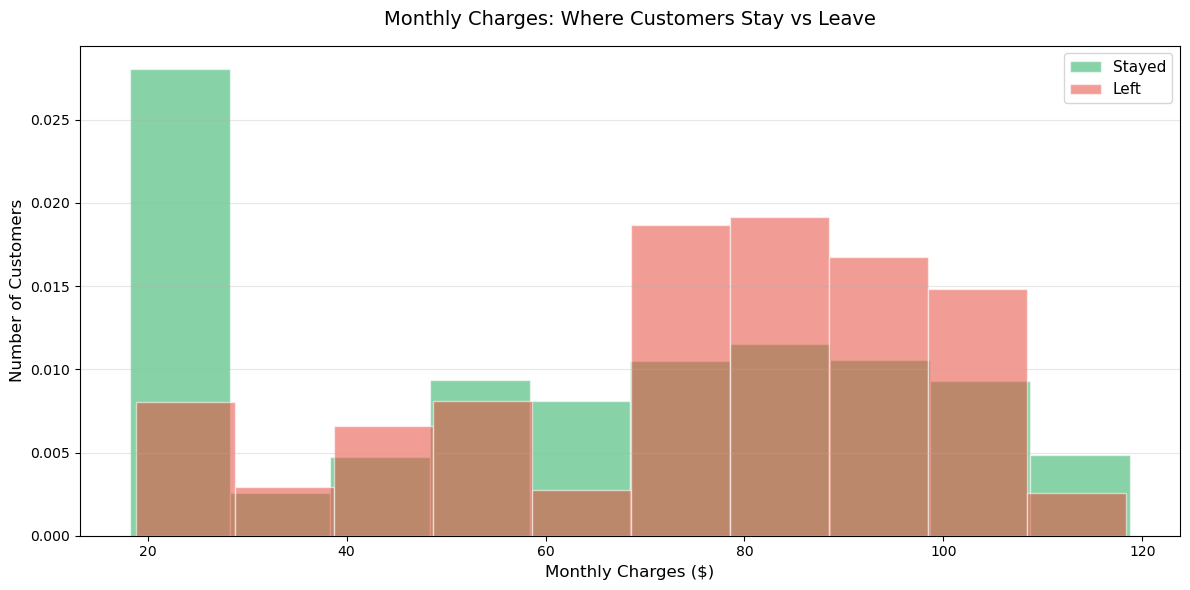

In [323]:
stayed = df[df['Churn'] == 0]['MonthlyCharges']
churned = df[df['Churn'] == 1]['MonthlyCharges']

plt.figure(figsize=(12, 6))

plt.hist(
    stayed,
    bins=10,
    alpha=0.55,
    label='Stayed',
    color='#27ae60',
    edgecolor='white',
    density=True
)

plt.hist(
    churned,
    bins=10,
    alpha=0.55,
    label='Left',
    color='#e74c3c',
    edgecolor='white',
    density=True
)

plt.title('Monthly Charges: Where Customers Stay vs Leave', fontsize=14, pad=15)
plt.xlabel('Monthly Charges ($)', fontsize=12)
plt.ylabel('Number of Customers', fontsize=12)
plt.legend(fontsize=11)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

C:\Users\jesse\AppData\Local\Temp\ipykernel_18700\931367494.py:3: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  churn_pct = df.groupby('ChargeBin', observed=True).apply(


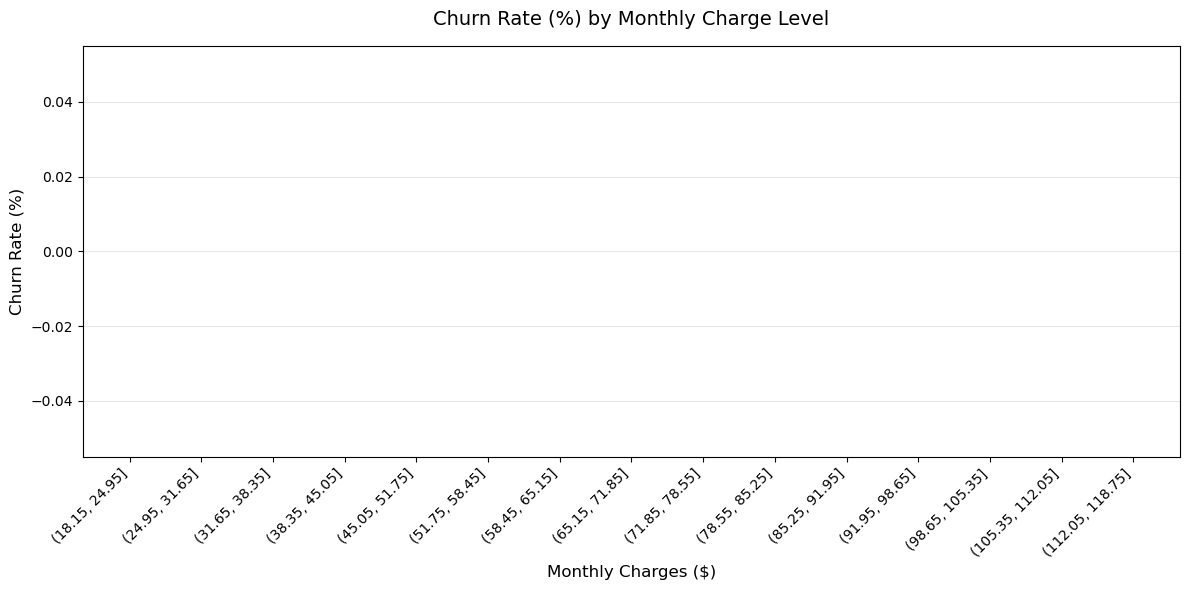

In [324]:
df['ChargeBin'] = pd.cut(df['MonthlyCharges'], bins=15)

churn_pct = df.groupby('ChargeBin', observed=True).apply(
    lambda x: (x['Churn'] == 'Yes').mean() * 100
)

plt.figure(figsize=(12, 6))
churn_pct.plot(kind='bar', color='#e74c3c', edgecolor='white', width=0.8)

plt.title('Churn Rate (%) by Monthly Charge Level', fontsize=14, pad=15)
plt.xlabel('Monthly Charges ($)', fontsize=12)
plt.ylabel('Churn Rate (%)', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()


# Checking counts of Internet services

In [325]:
df['OnlineSecurity'].value_counts()

OnlineSecurity
No                     3498
Yes                    2019
No internet service    1526
Name: count, dtype: int64

In [326]:
df['TechSupport'].value_counts()

TechSupport
No                     3473
Yes                    2044
No internet service    1526
Name: count, dtype: int64

In [327]:
df['InternetService'].value_counts()

InternetService
Fiber optic    3096
DSL            2421
No             1526
Name: count, dtype: int64

In [328]:
df['Contract'].value_counts()

Contract
Month-to-month    3875
Two year          1695
One year          1473
Name: count, dtype: int64

# 4. Modeling Approach

Model used was XGB classifier. 
parameters were determined by utilizing gridsearchCV to look at the best precision score. Validation data set made from splitting was used to tweak and verify.

1. Contract, internet service, 

2. Model peformance:

on validation set:
-  accuracy:  0.7814052519517388
-  precision:  0.7028571428571428
-  recall:  0.3245382585751979

on test set:
-  accuracy:  0.8019872249822569
-  precision:  0.7554347826086957
-  recall:  0.3726541554959786


Model: XGBClassifier
-  n_estimators=100
-  learning_rate=0.01 
-  random_state=42

# 5. Key Results and Recommendations

-  Fix your fiber network and put in the contract that no other compaines can utilize your infrastructure.
-  Lock all customers into 1-2 year contracts and reward loyalty (tenure).

In [329]:
import shap 

In [330]:
shap._version

<module 'shap._version' from 'c:\\Users\\jesse\\anaconda3\\Lib\\site-packages\\shap\\_version.py'>

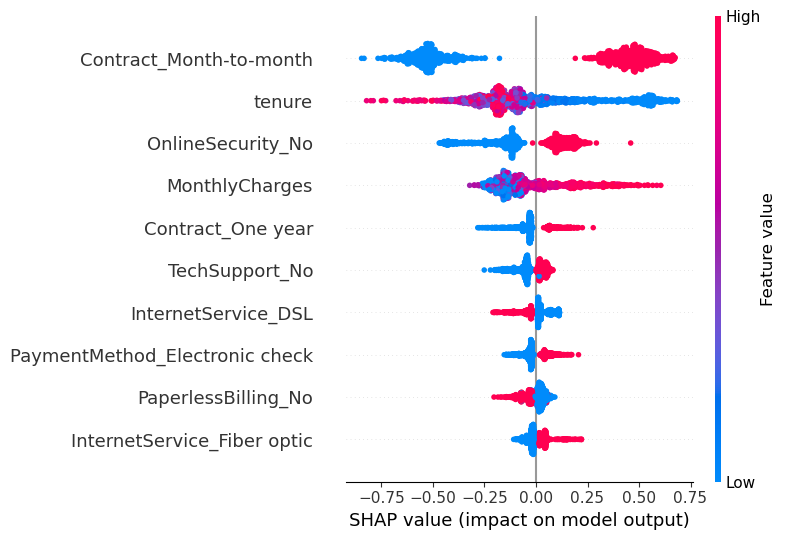

In [331]:
preprocessor = pipe[:-1]      # All steps up to the final model
final_model = pipe[-1]        # The actual model estimator

# 2. Transform the input data through the preprocessing steps
X_train_transformed = preprocessor.transform(X_train),
X_test_transformed = preprocessor.transform(X_test)

# 3. Pass the final model and transformed data to TreeExplainer
explainer = shap.TreeExplainer(final_model)
shap_values = explainer(X_test_transformed)

shap.summary_plot(shap_values, X_test_transformed, feature_names=feature_names, max_display=10)


# Semi-Correlation

<Axes: xlabel='InternetService'>

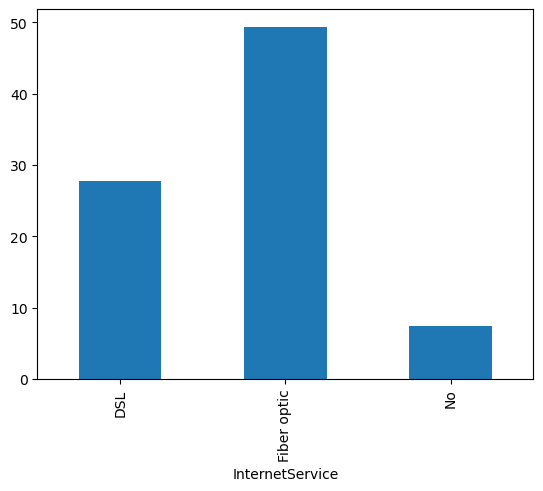

In [332]:
no_tech = df[df['TechSupport'] != 'Yes']

combo_churn = no_tech.groupby('InternetService')['Churn'].mean() *100

combo_churn.plot(kind='bar')

C:\Users\jesse\AppData\Local\Temp\ipykernel_18700\2150894614.py:5: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: (x['Churn'] == 1).mean() * 100)


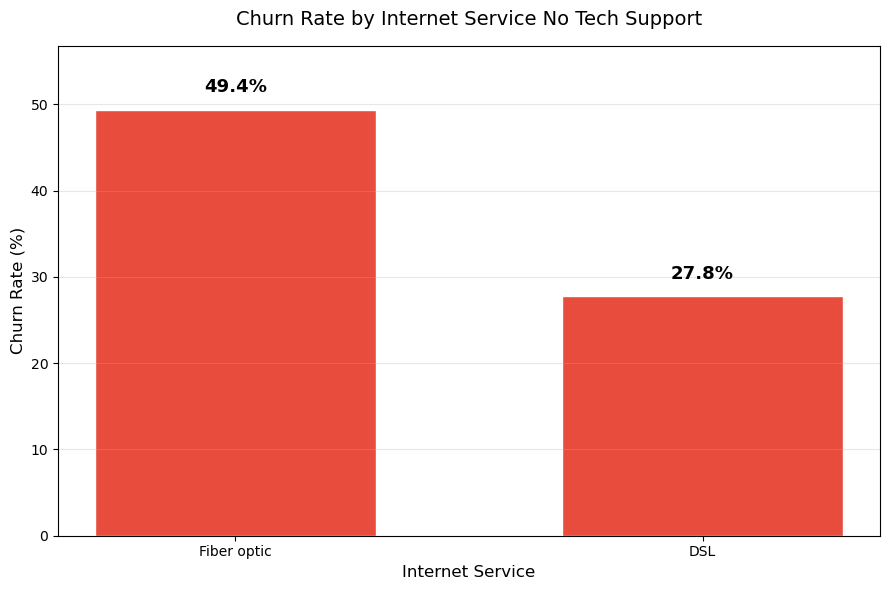

In [338]:
no_tech = df[df['TechSupport'] == 'No']

combo_churn = (
    no_tech.groupby('InternetService')
    .apply(lambda x: (x['Churn'] == 1).mean() * 100)
    .sort_values(ascending=False)
)

plt.figure(figsize=(9, 6))

bars = plt.bar(
    combo_churn.index,
    combo_churn.values,
    color='#e74c3c',
    edgecolor='white',
    width=0.6
)

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height + 2,
        f'{height:.1f}%',
        ha='center',
        fontsize=13,
        fontweight='bold'
    )

plt.title('Churn Rate by Internet Service No Tech Support', fontsize=14, pad=15)
plt.ylabel('Churn Rate (%)', fontsize=12)
plt.xlabel('Internet Service', fontsize=12)
plt.ylim(0, max(combo_churn.values) * 1.15)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# Correlation Speed Run - Probably None

In [336]:
df['OnlineSecurity'].value_counts()

OnlineSecurity
No                     3498
Yes                    2019
No internet service    1526
Name: count, dtype: int64

In [337]:
df['TechSupport_Num'] = df['TechSupport'].map({'No': -1, 'Yes': 1, 'No internet service':0})
df['OnlineSecurity_Num'] = df['OnlineSecurity'].map({'No': -1, 'Yes': 1, 'No internet service':0})
df.corr(numeric_only=True)

,SeniorCitizen,tenure,MonthlyCharges,Churn,TechSupport_Num,OnlineSecurity_Num
SeniorCitizen,1.000000,0.016567,0.220173,0.150889,-0.151268,-0.128221
tenure,0.016567,1.000000,0.247900,-0.352229,0.322942,0.325468
MonthlyCharges,0.220173,0.247900,1.000000,0.193356,-0.008682,-0.053878
Churn,0.150889,-0.352229,0.193356,1.000000,-0.282492,-0.289309
TechSupport_Num,-0.151268,0.322942,-0.008682,-0.282492,1.000000,0.285028
OnlineSecurity_Num,-0.128221,0.325468,-0.053878,-0.289309,0.285028,1.000000
